In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
data_news= pd.read_csv("C:/Users/WQM/Desktop/本科毕业论文/数据集/FNSPID/Stocknews.csv", dtype= str)
data_news= pd.DataFrame(data_news)

In [4]:
data_news['Year'] = pd.to_datetime(data_news['Date']).dt.year
data_news['Month'] = pd.to_datetime(data_news['Date']).dt.month
data_news['Day'] = pd.to_datetime(data_news['Date']).dt.day

In [9]:
data_news['Date'].min()

'1969-12-31'

In [8]:
data_news['Date'].max()

'2020-06-11'

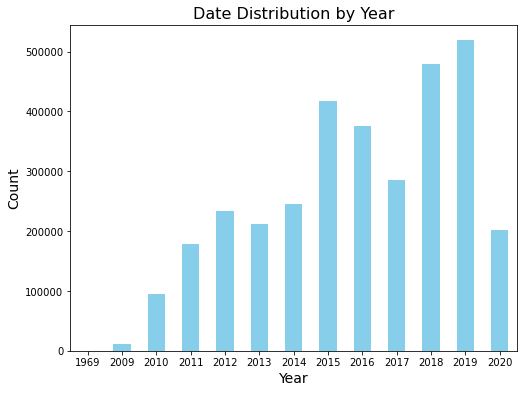

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 计算每年出现的日期数量
yearly_counts = data_news['Year'].value_counts().sort_index()

# 绘制柱状图
plt.figure(figsize=(8, 6))
yearly_counts.plot(kind='bar', color='skyblue')

# 添加标题和标签
plt.title('Date Distribution by Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Count', fontsize=14)

# 显示图表
plt.xticks(rotation=0)
plt.show()

In [13]:
# 筛选年份在2010到2020之间的行
data_news2 = data_news[(data_news['Year'] >= 2010) & (data_news['Year'] <= 2020)]

In [ ]:
# 删除重复的行
data_news2.drop_duplicates(inplace= True)

In [23]:
# 整理dataframe顺序
data_news3 = data_news2.sort_values(by=['Date', 'Stock_symbol'], ascending=[True, True])
data_news3.reset_index(drop= True, inplace= True)

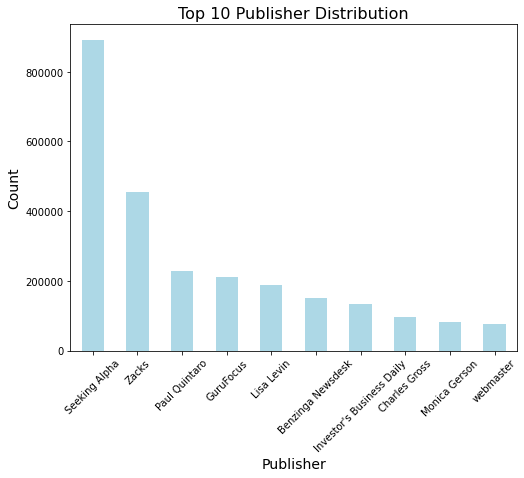

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# 统计每个Publisher的数量
publisher_counts = data_news3['Publisher'].value_counts().head(10)

# 绘制柱状图
plt.figure(figsize=(8, 6))
publisher_counts.plot(kind='bar', color='lightblue')

# 添加标题和标签
plt.title('Top 10 Publisher Distribution', fontsize=16)
plt.xlabel('Publisher', fontsize=14)
plt.ylabel('Count', fontsize=14)

# 显示图表
plt.xticks(rotation=45)
plt.show()

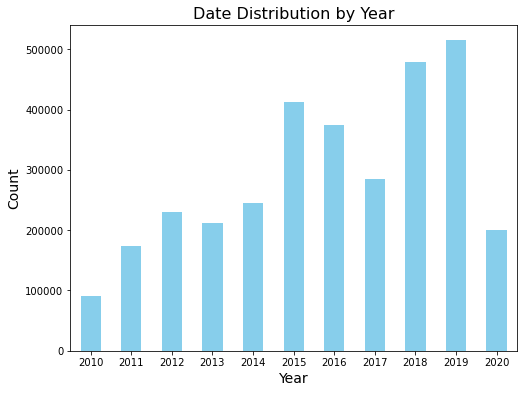

In [40]:
# 计算每年出现的日期数量
yearly_counts = data_news3['Year'].value_counts().sort_index()

# 绘制柱状图
plt.figure(figsize=(8, 6))
yearly_counts.plot(kind='bar', color='skyblue')

# 添加标题和标签
plt.title('Date Distribution by Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Count', fontsize=14)

# 显示图表
plt.xticks(rotation=0)
plt.show()

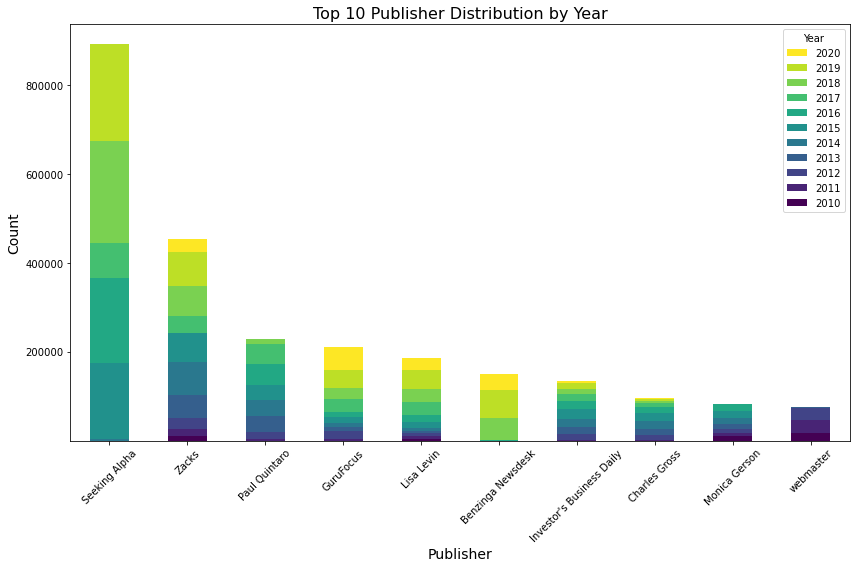

In [39]:
# 计算每个Publisher在每一年出现的次数
publisher_year_counts = data_news3.groupby(['Publisher', 'Year']).size().unstack(fill_value=0)

# 只保留出现次数最多的前10个Publisher
top_publishers = data_news3['Publisher'].value_counts().head(10).index
publisher_year_counts = publisher_year_counts.loc[top_publishers]

# 获取年份列表
years = publisher_year_counts.columns

# 为不同年份创建渐变色
colors = plt.cm.viridis(np.linspace(0, 1, len(years)))

# 绘制堆叠柱状图
ax = publisher_year_counts.plot(kind='bar', stacked=True, figsize=(12, 8), color=colors)

# 添加标题和标签
plt.title('Top 10 Publisher Distribution by Year', fontsize=16)
plt.xlabel('Publisher', fontsize=14)
plt.ylabel('Count', fontsize=14)

# 调整图例顺序
handles, labels = ax.get_legend_handles_labels()
# 创建一个字典，将年份与图例句柄映射在一起
legend_dict = dict(zip(labels, handles))
# 按年份降序排序字典
sorted_labels = sorted(legend_dict.keys(), reverse=True)
sorted_handles = [legend_dict[label] for label in sorted_labels]
# 设置图例
plt.legend(sorted_handles, sorted_labels, title='Year')

# 显示图表
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
data_news3.to_csv("Processed_external2.csv", index= False)

In [43]:
data_news4= data_news3.loc[:, ['Date', 'Article_title', 'Stock_symbol']]

In [45]:
data_news4.drop_duplicates(inplace= True)

In [49]:
import re

# 辅助函数来处理标题的末尾
def ensure_punctuation(title):
    if not re.search(r'[.!?]$', title):
        return title + '.'
    return title

# 应用辅助函数处理每个标题
data_news4['Article_title'] = data_news4['Article_title'].apply(ensure_punctuation)

# 对DataFrame进行分组并合并
data_news5 = (data_news4.groupby(['Date', 'Stock_symbol'])['Article_title'].agg(lambda x: ' '.join(x)).reset_index())

In [50]:
data_news5

,Date,Stock_symbol,Article_title
0,2010-01-01,DRR,Sizemore Capital 2009 Year End Investment Outl...
1,2010-01-01,EWT,Sizemore Capital 2009 Year End Investment Outl...
2,2010-01-01,EWZ,Sizemore Capital 2009 Year End Investment Outl...
3,2010-01-01,LQD,Sizemore Capital 2009 Year End Investment Outl...
4,2010-01-01,XLU,Sizemore Capital 2009 Year End Investment Outl...
...,...,...,...
1883554,2020-06-11,XRX,Shares of several technology companies are tra...
1883555,2020-06-11,XYL,Shares of several industrials companies are tr...
1883556,2020-06-11,YELP,BTIG Initiates Coverage On Yelp with Neutral R...
1883557,2020-06-11,YUM,Yum! Brands Files Lawsuit Against GrubHub Rela...


In [46]:
data_news4

,Date,Article_title,Stock_symbol
0,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,DRR
1,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,EWT
2,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,EWZ
3,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,LQD
4,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,XLU
...,...,...,...
3218136,2020-06-11,"Shares of several hotels, restaurants & leisur...",YUM
3218137,2020-06-11,Morgan Stanley Maintains Overweight on Yum Bra...,YUM
3218138,2020-06-11,"Credit Suisse Maintains Neutral on Yum Brands,...",YUM
3218139,2020-06-11,"UBS Maintains Buy on Yum Brands, Raises Price ...",YUM


In [41]:
data_news3

,Date,Article_title,Stock_symbol,Publisher,Year,Month,Day
0,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,DRR,Charles Lewis Sizemore CFA,2010,1,1
1,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,EWT,Charles Lewis Sizemore CFA,2010,1,1
2,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,EWZ,Charles Lewis Sizemore CFA,2010,1,1
3,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,LQD,Charles Lewis Sizemore CFA,2010,1,1
4,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,XLU,Charles Lewis Sizemore CFA,2010,1,1
...,...,...,...,...,...,...,...
3218136,2020-06-11,"Shares of several hotels, restaurants & leisur...",YUM,Benzinga Newsdesk,2020,6,11
3218137,2020-06-11,Morgan Stanley Maintains Overweight on Yum Bra...,YUM,Benzinga Newsdesk,2020,6,11
3218138,2020-06-11,"Credit Suisse Maintains Neutral on Yum Brands,...",YUM,Benzinga Newsdesk,2020,6,11
3218139,2020-06-11,"UBS Maintains Buy on Yum Brands, Raises Price ...",YUM,Benzinga Newsdesk,2020,6,11


In [36]:
publisher_year_counts

Year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
Seeking Alpha,0,0,0,0,3529,170683,191309,78676,229267,218062,0
Zacks,10375,15241,25087,52525,73358,64200,1329,38892,65875,76717,29972
Paul Quintaro,0,3036,15819,37118,36283,32714,47279,44828,10634,0,0
GuruFocus,0,3239,18586,8694,10017,12687,11371,28744,24551,41625,51208
Lisa Levin,3227,7415,5867,5106,6397,12550,16698,28572,30132,42668,28071
Benzinga Newsdesk,0,0,0,0,0,5,130,277,50806,61479,37695
Investor's Business Daily,0,1235,13226,15887,18570,20992,19711,15628,10243,13336,4642
Charles Gross,0,885,11682,12460,18728,18021,14674,8824,3732,5122,2469
Monica Gerson,10963,6556,7982,10619,13957,15400,15582,24,0,0,0
webmaster,17804,29264,25269,3216,519,2,0,0,0,0,0


In [25]:
data_news3

,Date,Article_title,Stock_symbol,Publisher,Year,Month,Day
0,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,DRR,Charles Lewis Sizemore CFA,2010,1,1
1,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,EWT,Charles Lewis Sizemore CFA,2010,1,1
2,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,EWZ,Charles Lewis Sizemore CFA,2010,1,1
3,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,LQD,Charles Lewis Sizemore CFA,2010,1,1
4,2010-01-01,Sizemore Capital 2009 Year End Investment Outl...,XLU,Charles Lewis Sizemore CFA,2010,1,1
...,...,...,...,...,...,...,...
3218136,2020-06-11,"Shares of several hotels, restaurants & leisur...",YUM,Benzinga Newsdesk,2020,6,11
3218137,2020-06-11,Morgan Stanley Maintains Overweight on Yum Bra...,YUM,Benzinga Newsdesk,2020,6,11
3218138,2020-06-11,"Credit Suisse Maintains Neutral on Yum Brands,...",YUM,Benzinga Newsdesk,2020,6,11
3218139,2020-06-11,"UBS Maintains Buy on Yum Brands, Raises Price ...",YUM,Benzinga Newsdesk,2020,6,11
